# Feature Engineering

## Objective

The objective of this notebook is to create predictive variables that better capture borrower credit risk and improve the performance of the Probability of Default (PD) model. 

## Analysis Overview

This notebook covers the following feature engineering activities:

- **Ratio Feature Engineering:** Create financial ratio variables that better represent borrower leverage, repayment burden, and credit utilization.
- **Employment Stability:** Transform employment length into broader categories to improve model robustness and reduce noise.
- **Categorical Feature Engineering:** Group infrequent categories to improve model stability and prepare variables for encoding.
- **Numerical Feature Transformation:** Apply transformations to highly skewed variables to improve their distributions and model performance.
- **Feature Preparation:** Create a modelling-ready dataset for subsequent feature selection, encoding, and Probability of Default (PD) model development.

## Deliverables

The output of this notebook includes:

- **Feature Engineered Dataset:** A transformed dataset containing newly derived variables and prepared features for modelling.

> **Note:** Based on the exploratory data analysis presented in Notebook 02, "Grade", "Loan Amount", "Debt-to-Income", "Loan Purpose", "Installment", "Verified Income" demonstrated meaningful relationships with observed default behaviour and are therefore retained as core candidate predictors for further statistical evaluation.

In [186]:
import pandas as pd
import numpy as np
from category_encoders import WOEEncoder

In [187]:
RAW_DATA = "../data/loan_raw.csv"
df = pd.read_csv(RAW_DATA)
df_fe = df.copy()

In [188]:
df_fe.info()
df_fe.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 55 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   emp_title                         9167 non-null   object 
 1   emp_length                        9183 non-null   float64
 2   state                             10000 non-null  object 
 3   homeownership                     10000 non-null  object 
 4   annual_income                     10000 non-null  float64
 5   verified_income                   10000 non-null  object 
 6   debt_to_income                    9976 non-null   float64
 7   annual_income_joint               1495 non-null   float64
 8   verification_income_joint         1455 non-null   object 
 9   debt_to_income_joint              1495 non-null   float64
 10  delinq_2y                         10000 non-null  int64  
 11  months_since_last_delinq          4342 non-null   float64
 12  earli

,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,...,C3,Mar-18,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,...,C1,Feb-18,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,...,D1,Feb-18,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,...,A3,Jan-18,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,...,C3,Mar-18,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


In [189]:
epsilon = 1e-6

df_fe["credit_utilization_ratio"] = (
    df_fe["total_credit_utilized"] /
    (df_fe["total_credit_limit"] + epsilon)
)

df_fe["monthly_income"] = df_fe["annual_income"] / 12

df_fe["installment_burden"] = (
    df_fe["installment"] /
    (df_fe["monthly_income"] + epsilon)
)

df_fe["loan_to_income"] = (
    df_fe["loan_amount"] /
    (df_fe["annual_income"] + epsilon)
)


df_fe["available_credit"] = (
    df_fe["total_credit_limit"] -
    df_fe["total_credit_utilized"]
)

df_fe["credit_exposure_multiple"] = (
    df_fe["total_credit_limit"] /
    (df_fe["annual_income"] + epsilon)
)

df_fe["loan_to_credit_limit"] = (
    df_fe["loan_amount"] /
    (df_fe["total_credit_limit"] + epsilon)
)

In [190]:
def employment_group(years):
    if pd.isna(years):
        return "Unknown"
    elif years <= 2:
        return "New"
    elif years <= 7:
        return "Established"
    else:
        return "Long-term"

df_fe["employment_stability"] = df_fe["emp_length"].apply(employment_group)

In [191]:
def group_rare_categories(series, min_frequency=100):
    counts = series.value_counts()

    rare = counts[counts < min_frequency].index

    return series.replace(rare, "Other")

df_fe["purpose_grouped"] = group_rare_categories(df_fe["loan_purpose"])

df_fe["state_grouped"] = group_rare_categories(df_fe["state"])

df_fe["grade_grouped"] = group_rare_categories(df_fe["grade"])

df_fe["sub_grade_grouped"] = group_rare_categories(df_fe["sub_grade"])

In [192]:
skewed_columns = [
    "annual_income",
    "total_credit_limit",
    "total_credit_utilized",
    "loan_amount",
    "available_credit"
]

for col in skewed_columns:
    df_fe[f"log_{col}"] = np.log1p(df_fe[col])

c:\Users\Lindsey Wang\miniconda3\envs\dsi_participant\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [193]:
df_fe["loan_status"].value_counts()

default_status = [
    "Charged Off",
    "Late (31-120 days)"
]

df_fe["default_flag"] = (
    df_fe["loan_status"]
      .isin(default_status)
      .astype(int)
)

# Information Value (IV)

## Objective

Information Value (IV) is used to measure the predictive strength of each candidate variable by quantifying its ability to distinguish between defaulted and non-defaulted loans.

Continuous variables are first grouped into quantile-based bins, while categorical variables are evaluated using their existing categories. The Weight of Evidence (WOE) and Information Value (IV) are then calculated for each variable.

Variables with higher IV values demonstrate stronger predictive power and are preferred for inclusion in the PD model.

In [194]:
def calculate_iv(df, feature, target, bins=10, epsilon=0.5):
    
    data = df[[feature, target]].dropna().copy()

    # Numerical variables
    if pd.api.types.is_numeric_dtype(data[feature]):
        try:
            data["Bin"] = pd.qcut(
                data[feature],
                q=bins,
                duplicates="drop"
            )
        except:
            data["Bin"] = data[feature]
    else:
        data["Bin"] = data[feature]

    grouped = (
        data.groupby("Bin", observed=False)[target]
        .agg(["count", "sum"])
        .rename(columns={
            "count": "Total",
            "sum": "Bad"
        })
    )

    grouped["Good"] = grouped["Total"] - grouped["Bad"]

    grouped["Default Rate"] = (
        grouped["Bad"] /
        grouped["Total"]
    )

    # Flag sparse bins
    grouped["Sparse Bin"] = (
        (grouped["Bad"] < 5) |
        (grouped["Good"] < 5)
    )

    # Warnings
    if (grouped["Bad"] == 0).any():
        print(f"Warning: '{feature}' contains bins with zero defaults.")

    if (grouped["Good"] == 0).any():
        print(f"Warning: '{feature}' contains bins with zero non-defaults.")

    # Laplace smoothing
    grouped["Good %"] = (
        grouped["Good"] + epsilon
    ) / (
        grouped["Good"].sum() + epsilon * len(grouped)
    )

    grouped["Bad %"] = (
        grouped["Bad"] + epsilon
    ) / (
        grouped["Bad"].sum() + epsilon * len(grouped)
    )

    grouped["WOE"] = np.log(
        grouped["Good %"] /
        grouped["Bad %"]
    )

    grouped["IV"] = (
        grouped["Good %"] -
        grouped["Bad %"]
    ) * grouped["WOE"]

    grouped["Cumulative IV"] = grouped["IV"].cumsum()

    iv = grouped["IV"].sum()

    return grouped.round(4), iv

In [195]:
woe_table, iv = calculate_iv(
    df_fe,
    feature="loan_to_income",
    target="default_flag"
)

display(woe_table)

print(f"Information Value = {iv:.4f}")

,Total,Bad,Good,Default Rate,Sparse Bin,Good %,Bad %,WOE,IV,Cumulative IV
Bin,,,,,,,,,,
"(0.0002800000000000001, 0.0758]",1000,4,996,0.004,True,0.1003,0.0577,0.5534,0.0236,0.0236
"(0.0758, 0.109]",1004,10,994,0.010,False,0.1001,0.1346,-0.2959,0.0102,0.0338
"(0.109, 0.143]",996,7,989,0.007,False,0.0996,0.0962,0.0355,0.0001,0.0339
"(0.143, 0.174]",1000,5,995,0.005,False,0.1002,0.0705,0.3517,0.0105,0.0444
"(0.174, 0.208]",1000,5,995,0.005,False,0.1002,0.0705,0.3517,0.0105,0.0548
"(0.208, 0.25]",1000,7,993,0.007,False,0.1000,0.0962,0.0395,0.0002,0.0550
"(0.25, 0.298]",1000,3,997,0.003,True,0.1004,0.0449,0.8057,0.0448,0.0997
"(0.298, 0.36]",1003,12,991,0.012,False,0.0998,0.1603,-0.4733,0.0286,0.1283
"(0.36, 0.469]",1000,12,988,0.012,False,0.0995,0.1603,-0.4763,0.0289,0.1573


Information Value = 0.1581


In [196]:
candidate_variables = [

    "grade",
    "loan_amount",
    "debt_to_income",
    "loan_purpose",
    "verified_income",

    "loan_to_income",
    "installment_burden",
    "credit_utilization_ratio",
    "available_credit",
    "loan_to_credit_limit",
    "credit_exposure_multiple",
    "employment_stability"

]

In [197]:
iv_summary = []

for feature in candidate_variables:

    try:

        _, iv = calculate_iv(
            df_fe,
            feature,
            target="default_flag"
        )

        iv_summary.append({

            "Variable":feature,

            "Information Value":iv

        })

    except:

        continue

iv_summary = (
    pd.DataFrame(iv_summary)
    .sort_values(
        "Information Value",
        ascending=False
    )
)

def iv_strength(iv):
    
    if iv < 0.02:
        return "Not Predictive"

    elif iv < 0.10:
        return "Weak"

    elif iv < 0.30:
        return "Medium"

    elif iv < 0.50:
        return "Strong"

    else:
        return "Suspicious"
    
iv_summary["Predictive Strength"] = (
    iv_summary["Information Value"]
    .apply(iv_strength)
)

iv_summary

,Variable,Information Value,Predictive Strength
0,grade,0.491636,Strong
9,loan_to_credit_limit,0.364361,Strong
3,loan_purpose,0.284456,Medium
2,debt_to_income,0.216919,Medium
5,loan_to_income,0.158113,Medium
1,loan_amount,0.145977,Medium
6,installment_burden,0.139389,Medium
4,verified_income,0.126443,Medium
8,available_credit,0.125188,Medium
10,credit_exposure_multiple,0.088000,Weak


# Correlation Analysis

## Objective

The objective of this section is to identify highly correlated predictor variables that may provide redundant information to the PD model.

Strong correlations between candidate variables can lead to multicollinearity, unstable coefficient estimates, and reduced model interpretability. Pearson correlation coefficients are calculated for all numerical candidate variables, and highly correlated pairs are identified for further evaluation using Variance Inflation Factor (VIF) analysis.

In [198]:
numerical_features = [

    "loan_amount",
    "debt_to_income",
    "loan_to_income",
    "installment_burden",
    "available_credit",
    "loan_to_credit_limit",
    "credit_exposure_multiple",
    "credit_utilization_ratio"

]

In [199]:
corr_matrix = df_fe[numerical_features].corr(method="pearson")

corr_matrix.round(3)

,loan_amount,debt_to_income,loan_to_income,installment_burden,available_credit,loan_to_credit_limit,credit_exposure_multiple,credit_utilization_ratio
loan_amount,1.000,0.056,0.032,0.032,0.266,-0.016,0.005,-0.088
debt_to_income,0.056,1.000,0.543,0.537,0.008,-0.017,0.571,0.134
loan_to_income,0.032,0.543,1.000,0.992,-0.011,-0.001,0.585,0.004
installment_burden,0.032,0.537,0.992,1.000,-0.011,-0.001,0.590,0.004
available_credit,0.266,0.008,-0.011,-0.011,1.000,-0.011,0.017,-0.600
loan_to_credit_limit,-0.016,-0.017,-0.001,-0.001,-0.011,1.000,-0.000,-0.020
credit_exposure_multiple,0.005,0.571,0.585,0.590,0.017,-0.000,1.000,-0.019
credit_utilization_ratio,-0.088,0.134,0.004,0.004,-0.600,-0.020,-0.019,1.000


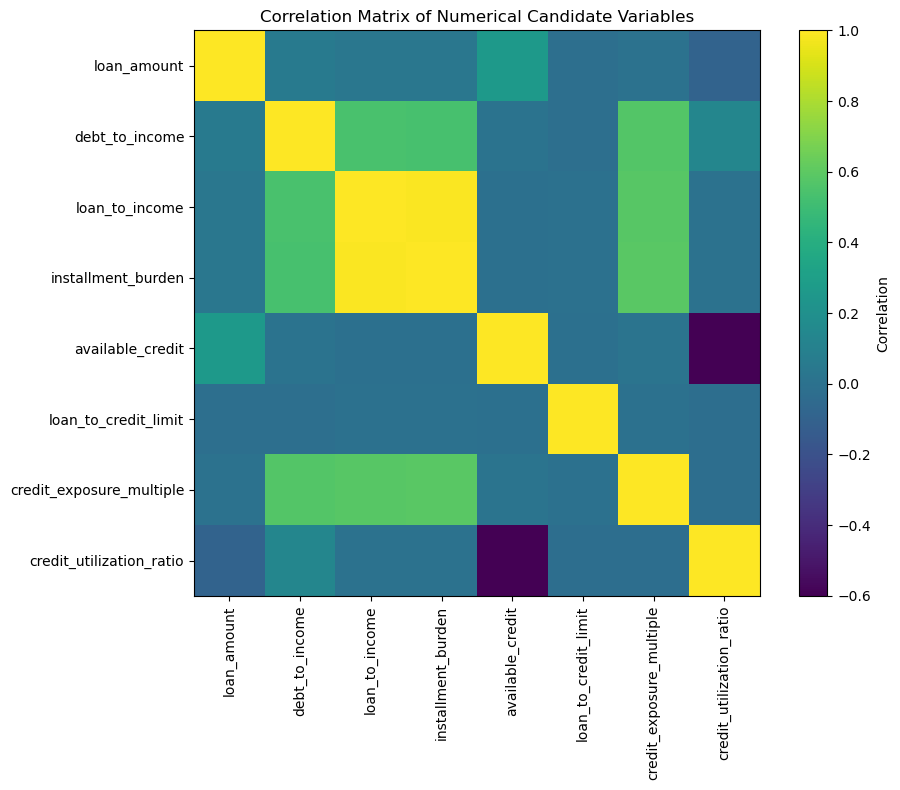

In [200]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.imshow(corr_matrix, interpolation="nearest")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Correlation Matrix of Numerical Candidate Variables")

plt.tight_layout()

plt.show()

In [201]:
corr_abs = corr_matrix.abs().copy()

# Ignore self-correlation
np.fill_diagonal(corr_abs.values, np.nan)

corr_rank = pd.DataFrame({
    "Variable": corr_abs.columns,
    "Most Correlated Variable": corr_abs.idxmax().values,
    "Highest Correlation": corr_abs.max().values
})

feature_summary = (
    iv_summary
    .merge(corr_rank, on="Variable", how="left")
)

feature_summary["Potential Redundancy"] = np.where(
    feature_summary["Highest Correlation"] >= 0.80,
    "Yes",
    "No"
)

feature_summary

,Variable,Information Value,Predictive Strength,Most Correlated Variable,Highest Correlation,Potential Redundancy
0,grade,0.491636,Strong,NaN,NaN,No
1,loan_to_credit_limit,0.364361,Strong,credit_utilization_ratio,0.020080,No
2,loan_purpose,0.284456,Medium,NaN,NaN,No
3,debt_to_income,0.216919,Medium,credit_exposure_multiple,0.570614,No
4,loan_to_income,0.158113,Medium,installment_burden,0.992420,Yes
5,loan_amount,0.145977,Medium,available_credit,0.266024,No
6,installment_burden,0.139389,Medium,loan_to_income,0.992420,Yes
7,verified_income,0.126443,Medium,NaN,NaN,No
8,available_credit,0.125188,Medium,credit_utilization_ratio,0.600281,No
9,credit_exposure_multiple,0.088000,Weak,installment_burden,0.589946,No


# Multicollinearity Assessment (VIF)

## Objective

The objective of this section is to evaluate multicollinearity among the numerical candidate predictors using the Variance Inflation Factor (VIF).

While correlation analysis evaluates pairwise relationships between variables, VIF measures the extent to which a predictor can be explained by all other predictors simultaneously.

Variables with high VIF values may introduce instability into the logistic regression model and will be considered for removal or replacement during the final feature selection process.

In [202]:
X = df_fe[numerical_features].copy()

# Remove missing values
X = X.dropna()

In [203]:
vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [

    variance_inflation_factor(
        X.values,
        i
    )

    for i in range(X.shape[1])

]

vif = vif.sort_values(
    "VIF",
    ascending=False
)

def interpret_vif(v):
    
    if v < 5:
        return "Low"

    elif v < 10:
        return "Moderate"

    else:
        return "High"
    
vif["Multicollinearity"] = (
    vif["VIF"]
    .apply(interpret_vif)
)

In [204]:
feature_summary = feature_summary.merge(

    vif,

    on="Variable",

    how="left"

)

feature_summary

,Variable,Information Value,Predictive Strength,Most Correlated Variable,Highest Correlation,Potential Redundancy,VIF,Multicollinearity
0,grade,0.491636,Strong,NaN,NaN,No,NaN,NaN
1,loan_to_credit_limit,0.364361,Strong,credit_utilization_ratio,0.020080,No,1.000081,Low
2,loan_purpose,0.284456,Medium,NaN,NaN,No,NaN,NaN
3,debt_to_income,0.216919,Medium,credit_exposure_multiple,0.570614,No,5.569017,Moderate
4,loan_to_income,0.158113,Medium,installment_burden,0.992420,Yes,39.599235,High
5,loan_amount,0.145977,Medium,available_credit,0.266024,No,5.337920,Moderate
6,installment_burden,0.139389,Medium,loan_to_income,0.992420,Yes,35.382725,High
7,verified_income,0.126443,Medium,NaN,NaN,No,NaN,NaN
8,available_credit,0.125188,Medium,credit_utilization_ratio,0.600281,No,3.519182,Low
9,credit_exposure_multiple,0.088000,Weak,installment_burden,0.589946,No,4.943104,Low


In [205]:
selected_features = [

    "grade",
    "loan_to_credit_limit",
    "loan_purpose",
    "debt_to_income",
    "loan_amount",
    "verified_income",
    "available_credit"
]

In [206]:
FEATURE_DATA = "../outputs/loan_feature_engineered.csv"
df_fe.to_csv(FEATURE_DATA, index=False)